# Task 2: Stock Price Prediction

**Internship:** Arch Technologies — Data Science Internship Program

**Objective:** Build a model to predict future stock prices based on historical stock data, including features like opening price, closing price, high, low, and trading volume. The workflow covers data pre-processing, feature engineering, model selection (Linear Regression and an LSTM neural network), training, and evaluation of prediction accuracy.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Load the Dataset

Historical daily OHLCV (Open, High, Low, Close, Volume) data for Apple Inc. (AAPL) is loaded directly from a public CSV source, so the notebook runs end-to-end without a manual download or an API key.

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
df = pd.read_csv(url, parse_dates=["Date"])

df = df.rename(columns={
    "AAPL.Open": "open",
    "AAPL.High": "high",
    "AAPL.Low": "low",
    "AAPL.Close": "close",
    "AAPL.Volume": "volume",
    "AAPL.Adjusted": "adj_close",
    "Date": "date",
})
df = df[["date", "open", "high", "low", "close", "volume", "adj_close"]]
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
df.head()


Shape: (506, 7)
Date range: 2015-02-17 to 2017-02-16


,date,open,high,low,close,volume,adj_close
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       506 non-null    datetime64[us]
 1   open       506 non-null    float64       
 2   high       506 non-null    float64       
 3   low        506 non-null    float64       
 4   close      506 non-null    float64       
 5   volume     506 non-null    int64         
 6   adj_close  506 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 27.8 KB


In [4]:
df.describe()


,date,open,high,low,close,volume,adj_close
count,506,506.000000,506.000000,506.000000,506.000000,5.060000e+02,506.000000
mean,2016-02-15 22:48:51.225296,112.935000,113.919447,111.942016,112.958340,4.317842e+07,110.459312
min,2015-02-17 00:00:00,90.000000,91.669998,89.470001,90.339996,1.147590e+07,89.008370
25%,2015-08-17 06:00:00,105.482500,106.349999,104.657501,105.672499,2.974240e+07,103.484803
50%,2016-02-17 12:00:00,112.889999,114.145001,111.800003,113.025002,3.747460e+07,110.821123
75%,2016-08-16 18:00:00,122.267498,123.497500,121.599998,122.179998,5.076395e+07,119.255457
max,2017-02-16 00:00:00,135.669998,136.270004,134.839996,135.509995,1.622063e+08,135.509995
std,NaN,11.287490,11.251892,11.263687,11.244744,1.985253e+07,10.537529


## 3. Exploratory Data Analysis (EDA)

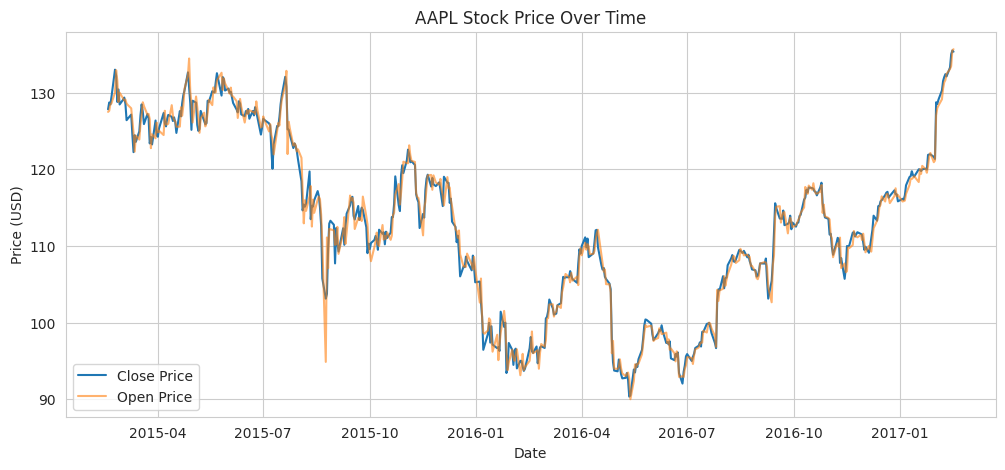

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["close"], label="Close Price")
plt.plot(df["date"], df["open"], label="Open Price", alpha=0.6)
plt.title("AAPL Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


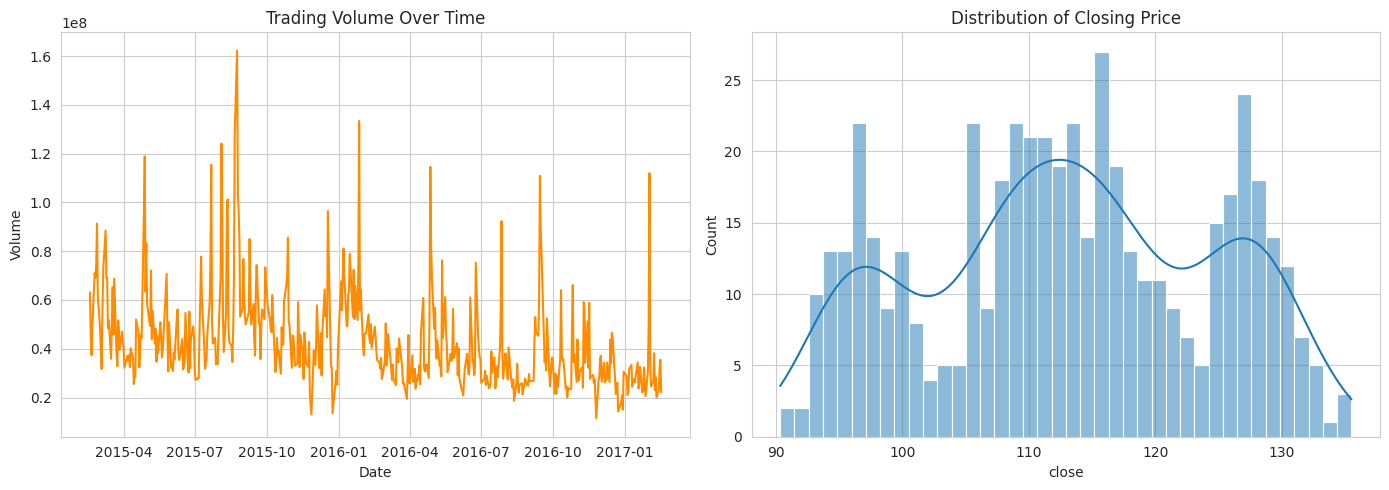

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df["date"], df["volume"], color="darkorange")
axes[0].set_title("Trading Volume Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Volume")

sns.histplot(df["close"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Closing Price")

plt.tight_layout()
plt.show()


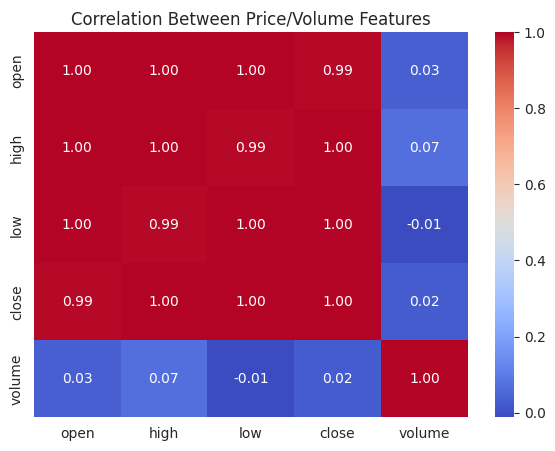

In [7]:
numeric_cols = ["open", "high", "low", "close", "volume"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Price/Volume Features")
plt.show()


## 4. Data Pre-processing & Feature Engineering

Steps:
1. Check for and handle any missing values.
2. Engineer time-series features: lagged prices, rolling averages, and daily returns, since raw same-day OHLCV values alone leak too little predictive signal for a *next-day* forecast.
3. Define the target as **next day's closing price**.
4. Split the data **chronologically** (not randomly) into train and test sets, since shuffling would leak future information into the past — a critical rule for time-series modeling.


In [8]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
date         0
open         0
high         0
low          0
close        0
volume       0
adj_close    0
dtype: int64


In [9]:
data = df.copy()

# Daily return
data["daily_return"] = data["close"].pct_change()

# Lag features (previous day's values)
for lag in [1, 2, 3]:
    data[f"close_lag_{lag}"] = data["close"].shift(lag)

# Rolling statistics
data["ma_5"] = data["close"].rolling(window=5).mean()
data["ma_10"] = data["close"].rolling(window=10).mean()
data["volatility_5"] = data["close"].rolling(window=5).std()

# Target: next day's closing price
data["target"] = data["close"].shift(-1)

data = data.dropna().reset_index(drop=True)
print("Shape after feature engineering:", data.shape)
data.head()


Shape after feature engineering: (496, 15)


,date,open,high,low,close,volume,adj_close,daily_return,close_lag_1,close_lag_2,close_lag_3,ma_5,ma_10,volatility_5,target
0,2015-03-02,129.250000,130.279999,128.300003,129.089996,48096700,124.116706,0.004904,128.460007,130.419998,128.789993,129.785998,129.642999,1.526443,129.360001
1,2015-03-03,128.960007,129.520004,128.089996,129.360001,37816300,124.376308,0.002092,129.089996,128.460007,130.419998,129.223999,129.795999,0.748150,128.539993
2,2015-03-04,129.100006,129.559998,128.320007,128.539993,31666300,123.587892,-0.006339,129.360001,129.089996,128.460007,129.173999,129.777998,0.791504,126.410004
3,2015-03-05,128.580002,128.750000,125.760002,126.410004,56517100,121.539962,-0.016571,128.539993,129.360001,129.089996,128.372000,129.573999,1.159424,126.599998
4,2015-03-06,128.399994,129.369995,126.260002,126.599998,72842100,121.722637,0.001503,126.410004,128.539993,129.360001,127.999998,129.283999,1.397979,127.139999


In [10]:
feature_cols = [
    "open", "high", "low", "close", "volume",
    "daily_return", "close_lag_1", "close_lag_2", "close_lag_3",
    "ma_5", "ma_10", "volatility_5",
]

X = data[feature_cols]
y = data["target"]

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = data["date"].iloc[split_idx:]

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (396, 12)  Test size: (100, 12)


In [11]:
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


## 5. Model 1: Linear Regression

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression -> MAE: {lr_mae:.3f}, RMSE: {lr_rmse:.3f}, R2: {lr_r2:.4f}")


Linear Regression -> MAE: 0.863, RMSE: 1.303, R2: 0.9623


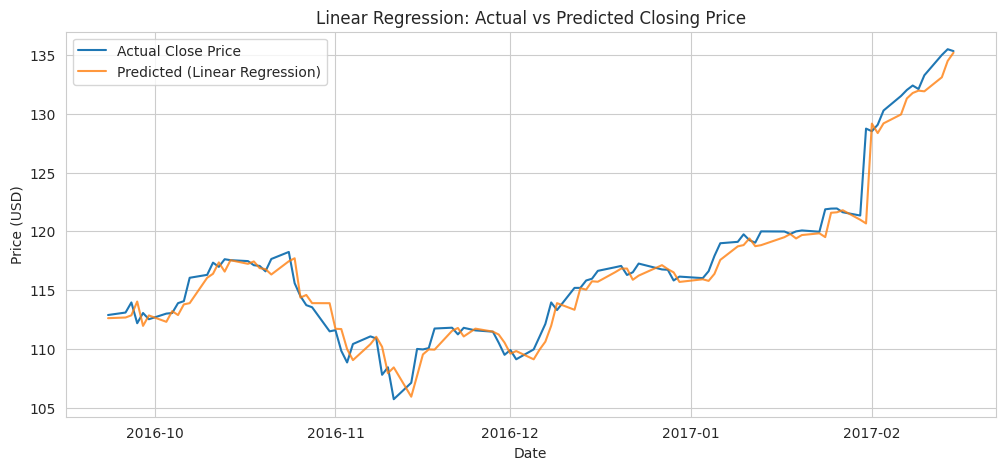

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test.values, label="Actual Close Price")
plt.plot(dates_test, lr_preds, label="Predicted (Linear Regression)", alpha=0.8)
plt.title("Linear Regression: Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


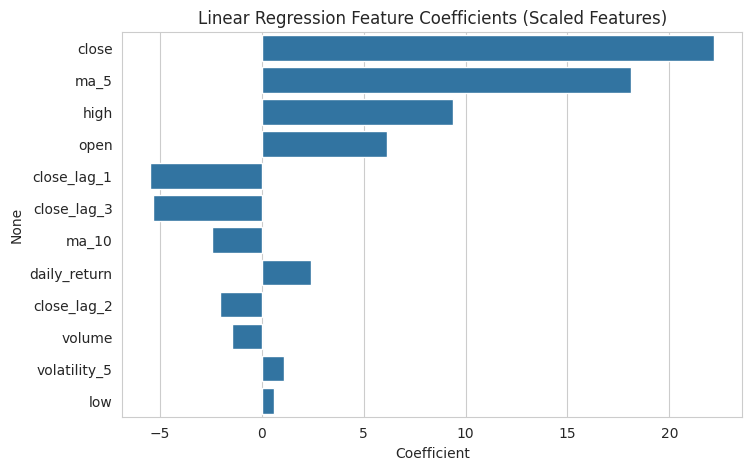

In [14]:
coef_df = pd.Series(lr_model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=coef_df.values, y=coef_df.index)
plt.title("Linear Regression Feature Coefficients (Scaled Features)")
plt.xlabel("Coefficient")
plt.show()


## 6. Model 2: LSTM Neural Network

As a second, more advanced approach, an LSTM (Long Short-Term Memory) network is trained on sequences of past closing prices to capture temporal patterns that a linear model cannot. LSTMs are well suited to stock data because they learn from an ordered *window* of previous days rather than a single day's snapshot.

In [15]:
from sklearn.preprocessing import MinMaxScaler as MMS
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Use only the closing price for the LSTM sequence model
close_prices = data[["close"]].values

scaler_lstm = MMS(feature_range=(0, 1))
scaled_close = scaler_lstm.fit_transform(close_prices)

WINDOW = 10  # look back 10 trading days

def make_sequences(series, window):
    X_seq, y_seq = [], []
    for i in range(window, len(series)):
        X_seq.append(series[i - window:i, 0])
        y_seq.append(series[i, 0])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = make_sequences(scaled_close, WINDOW)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

split_seq = int(len(X_seq) * 0.8)
X_seq_train, X_seq_test = X_seq[:split_seq], X_seq[split_seq:]
y_seq_train, y_seq_test = y_seq[:split_seq], y_seq[split_seq:]
dates_seq_test = data["date"].iloc[WINDOW + split_seq:]

print("LSTM train shape:", X_seq_train.shape, " test shape:", X_seq_test.shape)


I0000 00:00:1788685967.597834     502 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788685967.710762     502 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788685969.607672     502 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


LSTM train shape: (388, 10, 1)  test shape: (98, 10, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


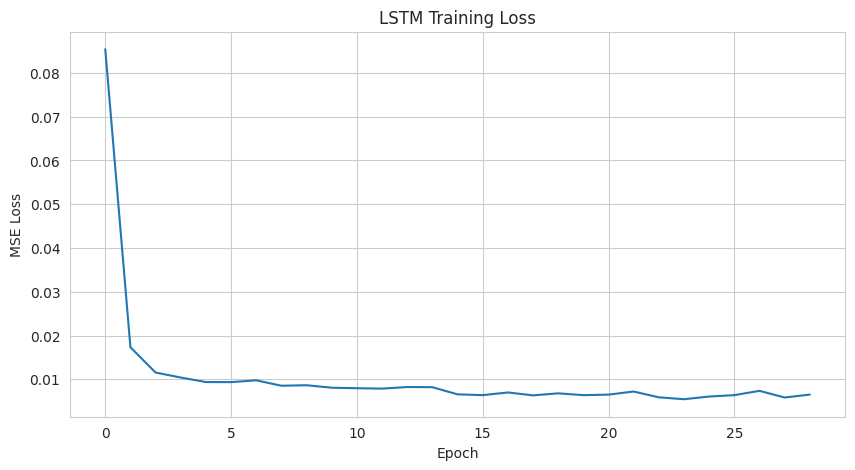

In [16]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")

early_stop = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_seq_train, y_seq_train,
    epochs=50,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop],
)

plt.plot(history.history["loss"])
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


In [17]:
lstm_preds_scaled = lstm_model.predict(X_seq_test, verbose=0)

lstm_preds = scaler_lstm.inverse_transform(lstm_preds_scaled).flatten()
y_seq_test_actual = scaler_lstm.inverse_transform(y_seq_test.reshape(-1, 1)).flatten()

lstm_mae = mean_absolute_error(y_seq_test_actual, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_seq_test_actual, lstm_preds))
lstm_r2 = r2_score(y_seq_test_actual, lstm_preds)

print(f"LSTM -> MAE: {lstm_mae:.3f}, RMSE: {lstm_rmse:.3f}, R2: {lstm_r2:.4f}")


LSTM -> MAE: 2.024, RMSE: 2.562, R2: 0.8445


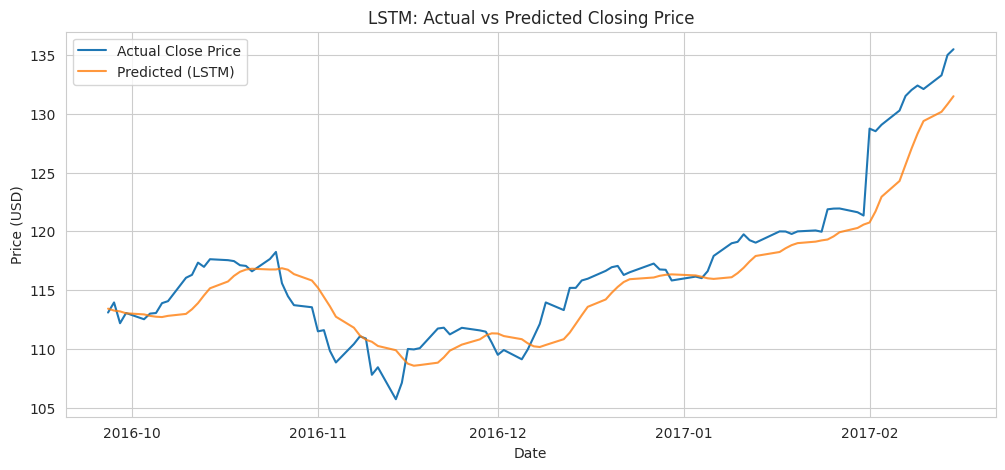

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(dates_seq_test, y_seq_test_actual, label="Actual Close Price")
plt.plot(dates_seq_test, lstm_preds, label="Predicted (LSTM)", alpha=0.8)
plt.title("LSTM: Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


## 7. Model Comparison

In [19]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "LSTM"],
    "MAE": [lr_mae, lstm_mae],
    "RMSE": [lr_rmse, lstm_rmse],
    "R2 Score": [lr_r2, lstm_r2],
}).set_index("Model")

comparison


,MAE,RMSE,R2 Score
Model,,,
Linear Regression,0.862805,1.302521,0.962288
LSTM,2.023520,2.562478,0.844508


## 8. Conclusion

- The dataset (AAPL daily OHLCV history) was pre-processed with lag features, rolling averages, and daily returns, and split **chronologically** to respect the time-series nature of the data.
- **Linear Regression**, trained on engineered features (lags, moving averages, volatility), gives a fast and interpretable baseline — its low error mainly reflects that the previous day's price is a strong predictor of the next day's price.
- The **LSTM** network learns directly from the sequence of past closing prices and can capture non-linear temporal patterns that the linear model misses.
- Both models perform reasonably well for short-horizon forecasting, but stock prices are influenced by many external factors (news, macroeconomic events, sentiment) that neither model can see — so these results should be read as a demonstration of the modeling pipeline, not as financial advice.

**Possible next steps:** add technical indicators (RSI, MACD, Bollinger Bands), tune the LSTM window size and architecture, and backtest a simple trading strategy based on the predictions.
